# Data Exploration

In this notebook, we will:
1. Load the `codification_data.csv`, `icd_d_p_pairs.csv`, and `leaderboard_data.csv` datasets.
2. Perform Exploratory Data Analysis (EDA) on the textual clinical notes and the ICD code distributions.
3. Identify the main challenges (e.g., class imbalance, sequence length).
4. Preprocess the data for the baseline non-deep learning models.

# 1. Setup: load libraries
Here we are initiating the necessary libraries and datasets to then make the exploratory.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

codif_df = pd.read_csv("../data/codification_data.csv")
icd_df     = pd.read_csv('../data/icd_d_p_pairs.csv')
lead_df    = pd.read_csv('../data/leaderboard_data.csv')

print("Train shape:",
codif_df.shape)
print("ICD dict shape:", icd_df.shape)
print("Test shape:", lead_df.shape)

display
codif_df.head(5)
display(icd_df.head(5))
display(lead_df.head(5))

Train shape: (13700, 2)
ICD dict shape: (179742, 3)
Test shape: (6667, 2)


,Code,D_P,Description
0,A00,D,Cólera
1,A000,D,"Cólera debido a Vibrio cholerae 01, biotipo ch..."
2,A001,D,"Cólera debido a Vibrio cholerae 01, biotipo El..."
3,A009,D,"Cólera, no especificado"
4,A01,D,Fiebres tifoidea y paratifoidea


,id,Literal
0,1,AMNIODRENAJE
1,2,Hiperparatiroidismo primario
2,3,MIGRANYA parto
3,4,VHC
4,5,Absceso mama izq


# 2. Basic dataset statistics

Here we will show important statistics like total training samples, total ICD entries, total test samples...

In [70]:
print("--- CODIFICATION ---")
display(codif_df.describe())
print("Total training samples: " + str(len(codif_df)))
print("Missing values: \n" + str(codif_df.isnull().sum()))

print("\n--- ICD ---")
display(icd_df.describe())
print("Total ICD entries: " + str(len(icd_df)))
print("Diagnosis codes (D) vs Procedure codes (P)")
print("(D): " + str((icd_df['D_P'] == 'D').sum())
     + "\n(P): " + str((icd_df['D_P'] == 'P').sum()))

print("--- LEADERBOARD ---")
print("Top 5:")
display(lead_df.head())
print("Last 5:")
display(lead_df.tail())
print("Total: " + str(len(lead_df)))

--- CODIFICATION ---


,Code,Literal
count,13700,13700
unique,4059,11584
top,Z6740,obesidad parto
freq,148,14


Total training samples: 13700
Missing values: 
Code       0
Literal    0
dtype: int64

--- ICD ---


,Code,D_P,Description
count,179742,179742,179742
unique,179742,2,174648
top,A00,D,Otros trastornos de rótula
freq,1,101246,4


Total ICD entries: 179742
Diagnosis codes (D) vs Procedure codes (P)
(D): 101246
(P): 78496
--- LEADERBOARD ---
Top 5:


,id,Literal
0,1,AMNIODRENAJE
1,2,Hiperparatiroidismo primario
2,3,MIGRANYA parto
3,4,VHC
4,5,Absceso mama izq


Last 5:


,id,Literal
6662,6663,gripe A
6663,6664,Polipos endometriales
6664,6665,Hèrnia ventral
6665,6666,CA PAPILAR
6666,6667,vancomicina


Total: 6667


# Label distribution analysis

Here we ask ourselfs:
- Are some ICD codes much more frequent than others?

=== Top 5 ===
        Count                                   Literal
Code                                                   
Z6740     148  Grupo sanguíneo materno: 0, Rh: Positivo
Z6710      93                          Grupo A positivo
Z3A40      87                                   SG:40+2
O99284     84                intolerancia Lactosa parto
Z886       71                        ALERGIA IBUPROFENO


=== Bottom 5 ===
         Count                        Literal
Code                                         
K2980        1                     DUODENITIS
0SBC0ZZ      1  meniscectomía rodilla derecha
2395         1            Tumor renal derecho
5952         1               cistitis cronica
L42          1              Pitiriasis rosada

Codes appearing only once: 1915
Codes appearing ≤ 5 times: 3498
Codes appearing > 50 times: 7


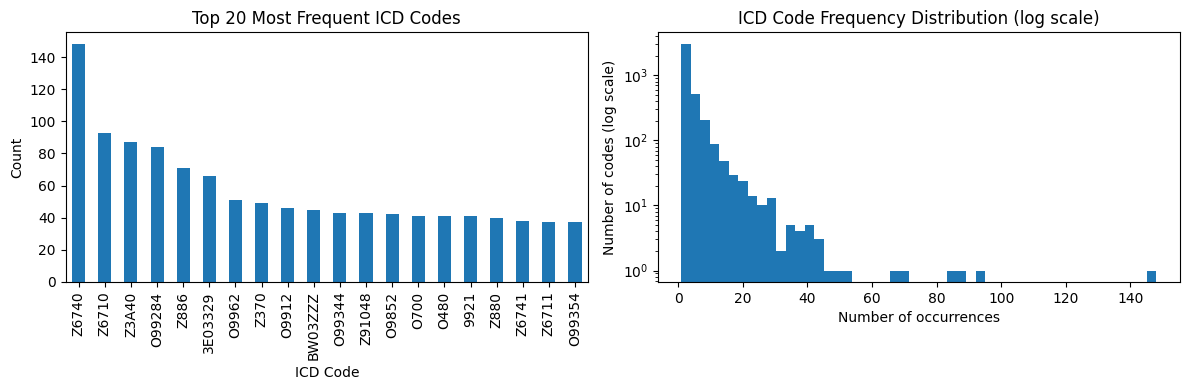

In [71]:
first_literals = codif_df.groupby('Code')['Literal'].first()

top_summary = code_counts.head().to_frame('Count')
top_summary['Literal'] = first_literals
print("=== Top 5 ===")
print(top_summary)

print("\n")

less_summary = code_counts.tail().to_frame('Count')
less_summary['Literal'] = first_literals
print("=== Bottom 5 ===")
print(less_summary)

print(f"\nCodes appearing only once: {(code_counts == 1).sum()}")
print(f"Codes appearing ≤ 5 times: {(code_counts <= 5).sum()}")
print(f"Codes appearing > 50 times: {(code_counts > 50).sum()}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
code_counts.head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent ICD Codes')
plt.xlabel('ICD Code')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(code_counts.values, bins=50, log=True)
plt.title('ICD Code Frequency Distribution (log scale)')
plt.xlabel('Number of occurrences')
plt.ylabel('Number of codes (log scale)')
plt.tight_layout()
plt.savefig('../docs/plots/label_distribution.png', dpi=150)
plt.show()


# Text / Literal analysis

Here we ask ourselfs:
- How long are the clinical text literals? 
- Are they short phrases or long documents?

=== LITERAL LENGTH STATS ===
       literal_length    word_count
count    13700.000000  13700.000000
mean        16.948321      2.210146
std          8.219715      1.014746
min          2.000000      1.000000
25%         11.000000      2.000000
50%         16.000000      2.000000
75%         22.000000      3.000000
max         63.000000      9.000000


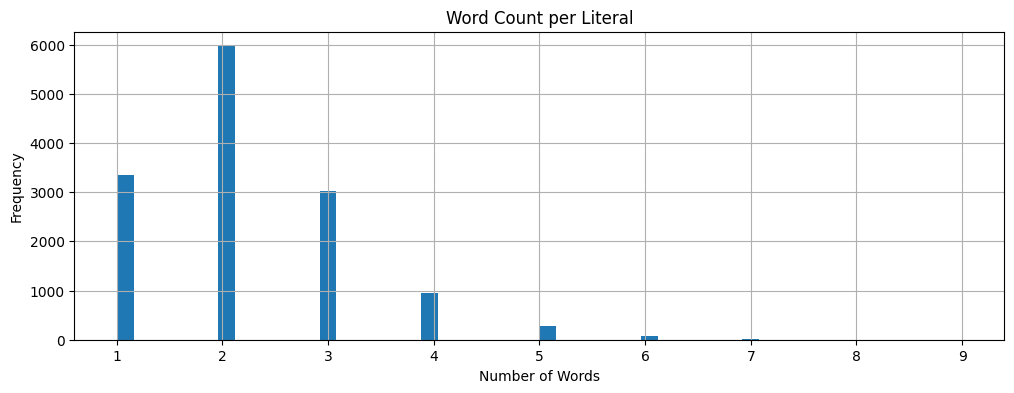

In [74]:
# Text length analysis
codif_df['literal_length'] = codif_df['Literal'].str.len()
codif_df['word_count'] = codif_df['Literal'].str.split().str.len()

print("=== LITERAL LENGTH STATS ===")
print(codif_df[['literal_length', 'word_count']].describe())

plt.figure(figsize=(12, 4))
codif_df['word_count'].hist(bins=50)
plt.title('Word Count per Literal')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.savefig('../docs/plots/text_lengths.png')
plt.show()